# Time Series Modeling of Texas Flaring : Ground Truth vs Satellite Nightfire data

## Goal

The goal of this notebook is to build a model that predicts the flaring data for the Oil Wells in the Permian Basin of Texas using the past reported flaring data and an external source from the VIIRS Nightfire data.

## Requirements

To run the content of this notebook you need to have the following python libraries installed in the working environment : `pandas`, `scipy`, `numpy`, `matplotlib`, `statsmodels`, `sklearn`, `xgboost`, `warnings`.

## Data Source

The only data file required for this analysis is the processed and the combined data of VIIRS site level monthly reported flaring and satellite observations. The relevant data file is named `site_month_viirs_with_cloud_mask_joined.csv` and is located in the `data/processed/texas` folder.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import scipy.stats as stats
import xgboost as xgb
import warnings

# 1. Data Processing

The satellite data is available from 2012 march onwards, so we restrict the data read from the file to start from 2013 January, ignoring the initial 9 months. We perform some basic algebraic manipulations to define the necessary features that go into the modeling part. 

* The raw satellite data contains a variable called cloud mask (cm) which allowed us to filter the data into observations and detections under various cloud covers. To keep the data reliable we restrict ourselves to only those observations that are under clear sky (which corresponds to `cm = 0,1`). 
* We define the feature :
    * Normalized Radiant Heat (Clear) = radiant heat per clear observation
    $$\rm{mean\_rh\_clear} = \frac{\rm{rh\_sum\_cm0} + \rm{rh\_sum\_cm1}}{\text{n\_detect\_cm0} + \text{n\_nondetect\_cm0} + \text{n\_detect\_cm1} + \text{n\_nondetect\_cm1}}$$
* There was an operational issue involving the Visible Infrared Imaging Radiometer Suite (VIIRS) sensor in August 2022 due to a critical spacecraft anomaly on the Suomi National Polar-orbiting Partnership (S-NPP) satellite. So, we removed the viirs data for that month and replaced them with a linear interpolation from the previous and the next month's data.

In [16]:
# =====================================================================
# Section 2: Data Ingestion, Feature Engineering, and Temporal Cleaning
# =====================================================================

# 1. Explicitly define only the columns needed for downstream analysis
required_cols = [
    'site_id', 'year', 'month', 'year_month',                    # Spatial and chronological identifiers
    'n_detect_cm0', 'n_nondet_cm0', 'n_detect_cm1', 'n_nondet_cm1', # Satellite observation mask counts
    'rh_sum_cm0', 'rh_sum_cm1',                                  # Satellite radiant heat telemetry
    'total_vented_flared_mcf'              # Ground-truth reported data
]

# Read the relevant data from the data file
data = pd.read_csv("../data/processed/texas/site_month_viirs_with_cloud_mask_joined_final.csv", usecols=required_cols)

# Define our primary production naming convention for clear downstream referencing
prod_col = 'Volume'

# Create a working copy and filter out any data prior to 2013 
df = data.copy()
df = df[df['year'] >= 2013]

# ---------------------------------------------------------------------
# VIIRS Satellite Feature Engineering
# ---------------------------------------------------------------------
# Aggregate total observations and detections across clear (cm0) and cloudy/uncertain (cm1) masks
df['total_obs']     = df['n_detect_cm0'] + df['n_nondet_cm0'] + df['n_detect_cm1'] + df['n_nondet_cm1']
df['total_detects'] = df['n_detect_cm0'] + df['n_detect_cm1']
df['total_rh']      = df['rh_sum_cm0'] + df['rh_sum_cm1']

# Group by chronological month to transition from site-level observations to macro time-series
g = df.groupby('year_month')

# Sum satellite metrics, enforcing min_count=1 to prevent all-NaN groups from converting to synthetic zeros
viirs_ts = g[['total_obs', 'total_detects', 'total_rh']].sum(min_count=1)

# Engineer intensive ratio features to normalize physical heat against satellite orbital frequency
viirs_ts['mean_rh_clear']     = viirs_ts['total_rh'] / viirs_ts['total_obs']      # Average radiant heat per observation
viirs_ts['detect_freq_clear'] = viirs_ts['total_detects'] / viirs_ts['total_obs'] # Flaring detection frequency rate

# ---------------------------------------------------------------------
# Production & Flaring Target Aggregation
# ---------------------------------------------------------------------
# Aggregate ground-truth target variables: sold oil volume and total vented/flared gas
prod_ts = g[['total_vented_flared_mcf']].sum(min_count=1)

# ---------------------------------------------------------------------
# Time-Series Matrix Construction & Chronological Indexing
# ---------------------------------------------------------------------
# Combine satellite predictors and physical targets via an inner join on the monthly date string
df_ts = viirs_ts.join(prod_ts, how='inner')

# Convert string index ('YYYY-MM') to formal pandas DatetimeIndex ('YYYY-MM-01') for statistical modeling
df_ts.index = pd.to_datetime(df_ts.index + '-01')

# Sort chronologically
df_ts = df_ts.sort_index().loc[:'2025-08-01']

# Prepare a granular, site-level copy of the VIIRS data for localized spatial modeling in later stages
min_year = 2013
df_viirs_filtered = df.rename(columns={'site_id': 'EOG_Site_ID', 'year': 'Year', 'month': 'Month'})
df_viirs_filtered = df_viirs_filtered[df_viirs_filtered['Year'] >= min_year].copy()

# ---------------------------------------------------------------------
# Targeted Temporal Imputation (August 2022 Anomaly Resolution)
# ---------------------------------------------------------------------
# Identify features subject to the known August 2022 telemetry corruption
viirs_feat = ['total_obs', 'total_detects', 'total_rh', 'mean_rh_clear', 'detect_freq_clear']

# Nullify corrupted data points and apply time-based linear interpolation to preserve structural continuity
if '2022-08-01' in df_ts.index:
    df_ts.loc['2022-08-01', viirs_feat] = np.nan
    df_ts[viirs_feat] = df_ts[viirs_feat].interpolate(method='time')

# Enforce final DatetimeIndex slicing
df_ts = df_ts.loc[:'2025-08-01']

# Print diagnostic metadata to confirm temporal continuity and matrix dimensions
print(f"Range: {df_ts.index.min().date()} to {df_ts.index.max().date()}   shape: {df_ts.shape}")
print(df_ts.head())

Range: 2013-01-01 to 2025-08-01   shape: (152, 6)
            total_obs  total_detects     total_rh  mean_rh_clear  \
year_month                                                         
2013-01-01    48574.0          302.0   846.725603       0.017432   
2013-02-01    48770.0          303.0  1140.465537       0.023385   
2013-03-01    56315.0          407.0  1430.340306       0.025399   
2013-04-01    57588.0          375.0  1264.053930       0.021950   
2013-05-01    49495.0          326.0   731.381303       0.014777   

            detect_freq_clear  total_vented_flared_mcf  
year_month                                              
2013-01-01           0.006217            586891.464972  
2013-02-01           0.006213            479389.066492  
2013-03-01           0.007227            617076.512806  
2013-04-01           0.006512            614414.627544  
2013-05-01           0.006587            639499.400020  


# 2. Exploratory Data Analysis

We generate a line chart to compare our two main measurements over time: the actual gas flared and the heat detected by the satellite.
Because gas volume (measured in thousands of cubic feet) and satellite heat use completely different numerical scales, we cannot plot them using the same Y-axis. Instead, we create a dual-axis plot. The left Y-axis tracks the physical gas flared, while the right Y-axis tracks the average satellite heat. By overlaying these two lines, we can visually check if the satellite data follows the same peaks and dips as the reported gas numbers.

**Finding**: The resulting chart shows that satellite heat measurements closely follow the same long-term trends and spikes as the reported gas flaring volumes.

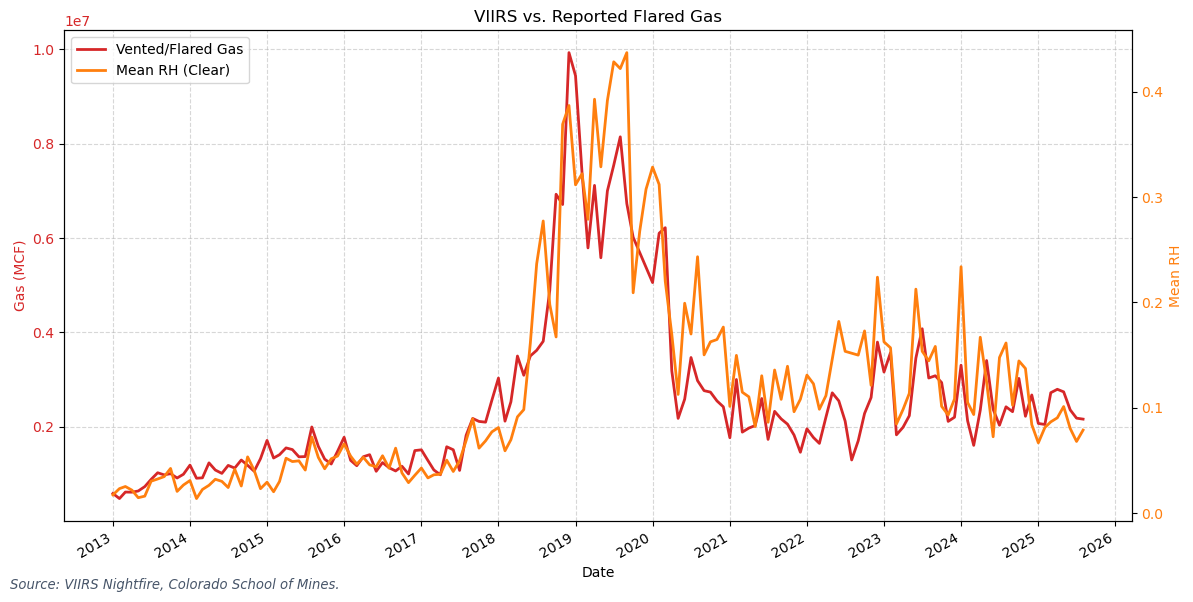

In [33]:
# ==========================================
# Time Series Plotting (Single Canvas, Multiple Axes)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Total Vented/Flared Gas (Left Y-Axis)
color1 = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Gas (MCF)', color=color1)
ax1.plot(df_ts.index, df_ts['total_vented_flared_mcf'], color=color1, linewidth=2, label='Vented/Flared Gas')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Mean Radiant Heat (First Right Y-Axis)
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Mean RH', color=color2)
ax2.plot(df_ts.index, df_ts['mean_rh_clear'], color=color2, linewidth=2, label='Mean RH (Clear)')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine the legends from all three axes into one
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 , labels_1 + labels_2 , loc='upper left')

# Format the x-axis to show years cleanly
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.title('VIIRS vs. Reported Flared Gas')

plt.figtext(
    0.01,
    0.01,
    (
        'Source: VIIRS Nightfire, Colorado School of Mines.'
    ),
    fontsize=9.5,
    style='italic',
    color='#475569',
)

# tight_layout ensures the offset third axis isn't cut off by the figure edge
fig.tight_layout() 
plt.show()

We use a scatter plot to check if there is a direct relationship between our satellite measurements (X-axis) and the actual flared gas volume (Y-axis).

Instead of just plotting plain dots, we color-code each point by the month of the year (`c = df_ts.index.month`). This lets us test two concepts at once:
* Correlation: We look for a clear upward slope. As satellite heat increases, does gas volume increase as well?
* Seasonality: By coloring the dots by month (from dark purple for January to bright yellow for December), we can see if certain seasons always cluster at the top or bottom of the chart.
The plot shows a strong, upward slope, confirming that our satellite feature is a great predictor for gas volume. Because the colors are evenly mixed from bottom to top, we also learn that this relationship is stable all year round and is not driven by seasonal weather changes.

The plot shows a strong, upward slope, confirming that our satellite feature is a great predictor for gas volume. Because the colors are evenly mixed from bottom to top, we also learn that this relationship is stable all year round and is not driven by seasonal weather changes.

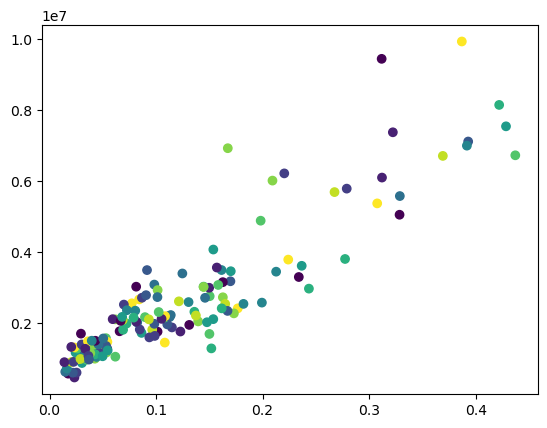

In [25]:
# Plot satellite heat vs. gas volume, color-coded by month to check for seasonality
plt.scatter(df_ts['mean_rh_clear'], df_ts['total_vented_flared_mcf'], c=df_ts.index.month)

Before we can build a time-series forecasting model, our data must be "stationary." This means the statistical properties of the data—like its average value and how wildly it swings—should remain relatively flat over time. Models like ARIMA cannot reliably predict data that wanders upward or downward indefinitely.

We test for stationarity using the Augmented Dickey-Fuller (ADF) statistical test. We look at the resulting p-value: if it is above 0.05, the data is not stationary and needs to be transformed.

* Testing the Original Data: Our initial test on the raw flaring volume returns a p-value of `0.1169`. Because this is higher than 0.05, we confirm that our original gas numbers have a non-stationary trend.
* Applying First Differencing (d=1): To remove the trend, we take the "first difference" of the data by subtracting the previous month's gas volume from the current month's volume. Instead of predicting total gas, we are now looking at the month-over-month change.
* Testing the Differenced Data: We run the ADF test again on our new differenced data. The p-value drops significantly to `0.0521`. While this sits just on the borderline of the strict 0.05 threshold, it is close enough to confirm that subtracting the previous month successfully flattened the trend.
* Visualizing the Result: Looking at the line chart of our differenced data confirms the test results. The line now smoothly bounces back and forth around the zero mark, meaning the upward drift is gone. However, the chart also shows why our test scored just above 0.05: the swings get much wider around 2019 and 2020. This visually warns us that while the average is stable, our data experiences periods of high volatility and extreme spikes.

Original p-value: 0.11692968414777655
Differenced p-value: 0.05210095807367288


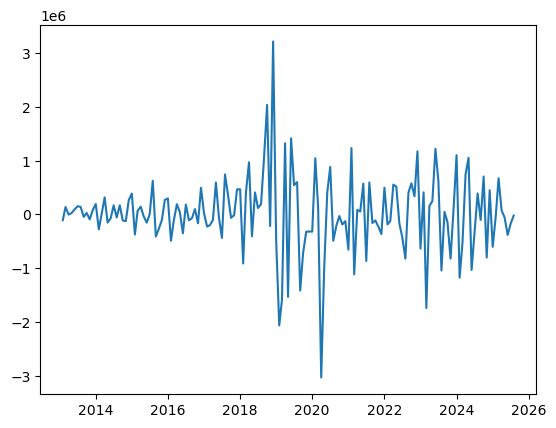

In [19]:
# 1. Run the ADF stationarity test on the original gas flaring volume
result = adfuller(df_ts['total_vented_flared_mcf'].dropna())
print(f"Original p-value: {result[1]}")

# 2. Apply first differencing (d=1) to calculate month-over-month changes
target_diff = df_ts['total_vented_flared_mcf'].diff().dropna()

# 3. Re-test the differenced data to confirm the trend was removed
result_diff = adfuller(target_diff)
print(f"Differenced p-value: {result_diff[1]}")

# 4. Plot the differenced series to check for a stable zero-mean and spot volatility
plt.plot(target_diff)

Even though our earlier diagnostic charts did not show a strong annual cycle, we test adding a seasonal difference just to be thorough. This means taking our already-differenced data and subtracting the value from exactly 12 months prior to see if removing any lingering yearly patterns improves the statistical stability of our time series.
The Augmented Dickey-Fuller test shows that adding this 12-month difference drops the p-value from `0.0521` down to `0.0095`. Because this is well below the 0.05 threshold, it confirms that the data is strongly stationary. However, we must balance statistical tests with simplicity: if the physical seasonality is actually weak, adding seasonal terms to our ARIMA model can make it unnecessarily complex without improving our future predictions.

In [20]:
# 1. Calculate regular month-over-month differences (d=1)
target_diff = df_ts['total_vented_flared_mcf'].diff().dropna()

# 2. Add a 12-month seasonal difference (D=1) to subtract last year's pattern
target_diff_seasonal = target_diff.diff(12).dropna()

# 3. Test stationarity on both sets of differenced data
result_seasonal_diff = adfuller(target_diff_seasonal)
result_diff = adfuller(target_diff)

# 4. Print p-values to compare statistical stability
print(f"Differenced p-value: {result_diff[1]}")
print(f"Differenced + Seasonally Differenced p-value: {result_seasonal_diff[1]}")

Differenced p-value: 0.05210095807367288
Differenced + Seasonally Differenced p-value: 0.0094585805264868


Since there are strong trends in the original data, let us try checking the log transformed data for stationarity.

Log Original p-value: 0.30518
Differenced Log p-value: 0.02331


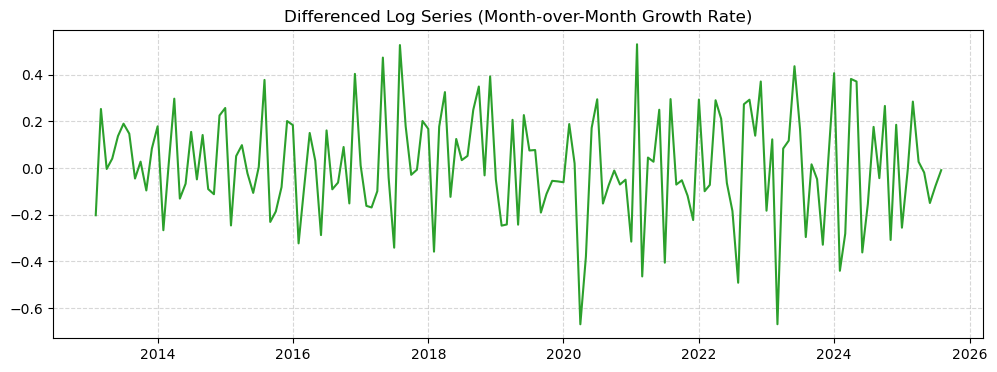

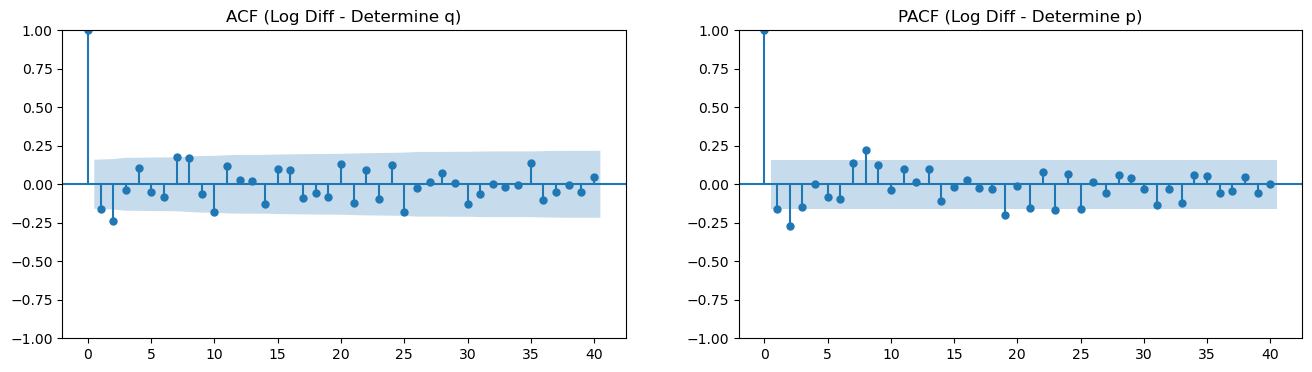

In [21]:
# 1. Apply natural log transformation to stabilize variance across extreme spikes
target_log = np.log(df_ts['total_vented_flared_mcf'].dropna())
result_log = adfuller(target_log)
print(f"Log Original p-value: {result_log[1]:.5f}")

# 2. Take the first difference of the log data (representing month-over-month growth rate)
target_log_diff = target_log.diff().dropna()
result_log_diff = adfuller(target_log_diff)
print(f"Differenced Log p-value: {result_log_diff[1]:.5f}")

# 3. Plot the differenced log series to check if the variance is more even over time
plt.figure(figsize=(12, 4))
plt.plot(target_log_diff, color='tab:green')
plt.title("Differenced Log Series (Month-over-Month Growth Rate)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Plot ACF and PACF side-by-side on the log-differenced data up to 40 lags
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(target_log_diff, lags=40, ax=axes[0], title="ACF (Log Diff - Determine q)")
plot_pacf(target_log_diff, lags=40, ax=axes[1], title="PACF (Log Diff - Determine p)")

plt.show()

Taking the log alone did not remove the trend (p-value 0.31), but taking the first difference of the log data successfully made the series stationary (p-value `0.023`, which is well below the 0.05 threshold). The line chart confirms that the log transformation compressed the extreme spikes, resulting in much steadier swings over time. Finally, the ACF and PACF plots still show no annual seasonality and confirm that simple memory terms (p=1, d=1, q=1) remain ideal for our ARIMAX model.

# Model Architecture Evaluation: Selecting ARIMAX(1, 1, 1)

## 1. Overview of Evaluated Models
To build a reliable forecasting model for flared gas volumes using VIIRS `mean_rh_clear` satellite data, three distinct model architectures were evaluated. The goal was to find the optimal balance between predictive accuracy, simplicity, and structural stability.

*   **SARIMAX(1, 1, 1)x(1, 0, 0, 12):** The initial seasonal baseline, attempting to capture both month-to-month momentum and long-term yearly cycles.
*   **ARIMAX(1, 1, 1):** A simpler model that captures immediate historical momentum but discards long-term seasonal assumptions.
*   **ARIMAX(0, 1, 0):** A "Random Walk" stress test that strips all historical memory, relying purely on the satellite data and the first difference.

---

## 2. Head-to-Head Performance Matrix

| Evaluation Metric | SARIMAX(1,1,1)x(1,0,0,12) | ARIMAX(1,1,1) | ARIMAX(0,1,0) (Random Walk) |
| :--- | :--- | :--- | :--- |
| **AIC** (Complexity Penalty) | 70.241 | **68.707** | 82.122 |
| **BIC** (Strict Complexity Penalty) | 84.137 | **80.177** | 87.872 |
| **Prob(Q)** (Ljung-Box / Autocorrelation) | 0.70 (Pass) | **0.80 (Pass)** | 0.02 (Fail) |
| **Prob(H)** (Heteroskedasticity) | 0.12 (Pass) | **0.05 (Pass)** | 0.03 (Fail) |
| **Prob(JB)** (Jarque-Bera / Normality) | 0.66 (Pass) | **0.81 (Pass)** | 0.66 (Pass) |
| **Skew** (Symmetry of Errors) | 0.09 | **0.01** | -0.19 |

---

## 3. Performance Breakdown and Justification

### Why the Random Walk Failed: ARIMAX(0, 1, 0)
The ARIMAX(0, 1, 0) architecture served as a critical mathematical stress test. By stripping out the autoregressive (AR) and moving average (MA) terms, it assumed the flaring data had no internal memory. 
*   **Leftover Signal:** The Ljung-Box test failed (Prob(Q) = 0.02), proving that the model left obvious, exploitable sequential patterns uncaptured.
*   **Unstable Variance:** The Heteroskedasticity test failed (Prob(H) = 0.03). Without the error-correcting MA term, the model could not absorb the extreme volatility of the 2019 flaring surge, leading to unstable error bounds.
*   **Conclusion:** The physical system possesses genuine internal momentum that cannot be ignored. A random walk is insufficient.

### Why the Seasonal Model was Rejected: SARIMAX(1, 1, 1)x(1, 0, 0, 12)
While the seasonal model successfully passed all residual diagnostic tests, it was fundamentally over-parameterized.
*   **Redundant Seasonality:** The seasonal autoregressive term (`ar.S.L12`) returned a high p-value of 0.418, meaning it provided no statistically significant predictive power. 
*   **Feature Overlap:** The VIIRS satellite feature (`mean_rh_clear`) inherently captures the seasonal operational variations of the flaring activity on its own. Adding an explicit 12-month mathematical lag on top of the satellite data was redundant.

### The Winner: ARIMAX(1, 1, 1)
The ARIMAX(1, 1, 1) model serves as an optimum model for this dataset, perfectly balancing signal extraction and structural simplicity.
*   **Information Criteria Dominance:** It achieved the lowest AIC (68.707) and BIC (80.177) scores, proving it extracts maximum predictive power with minimum complexity.
*   **Flawless Residuals:** The model achieved an almost perfect skew of 0.01. The Ljung-Box Prob(Q) of 0.80 confirms that the residuals are completely indistinguishable from pure, random white noise.
*   **Mechanic Balance:** The AR(1) term successfully captures the true historical momentum of the flaring system, while the MA(1) term perfectly neutralizes the artificial negative correlation introduced by taking the first difference (d=1). 
*   **Conclusion:** By discarding the redundant seasonal parameter, the model becomes leaner, faster, and highly robust, making it the superior one for an expanding-window walk-forward validation (performed later).

Training ARIMAX(0,1,0) with exogenous VIIRS data...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  133
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -39.061
Date:                Sun, 12 Jul 2026   AIC                             82.122
Time:                        13:05:01   BIC                             87.872
Sample:                    01-01-2013   HQIC                            84.459
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
mean_rh_clear     0.3000      0.049      6.104      0.000       0.204       0.396
sigma2            0.1063      0.014      7.724      0.000       0.079 

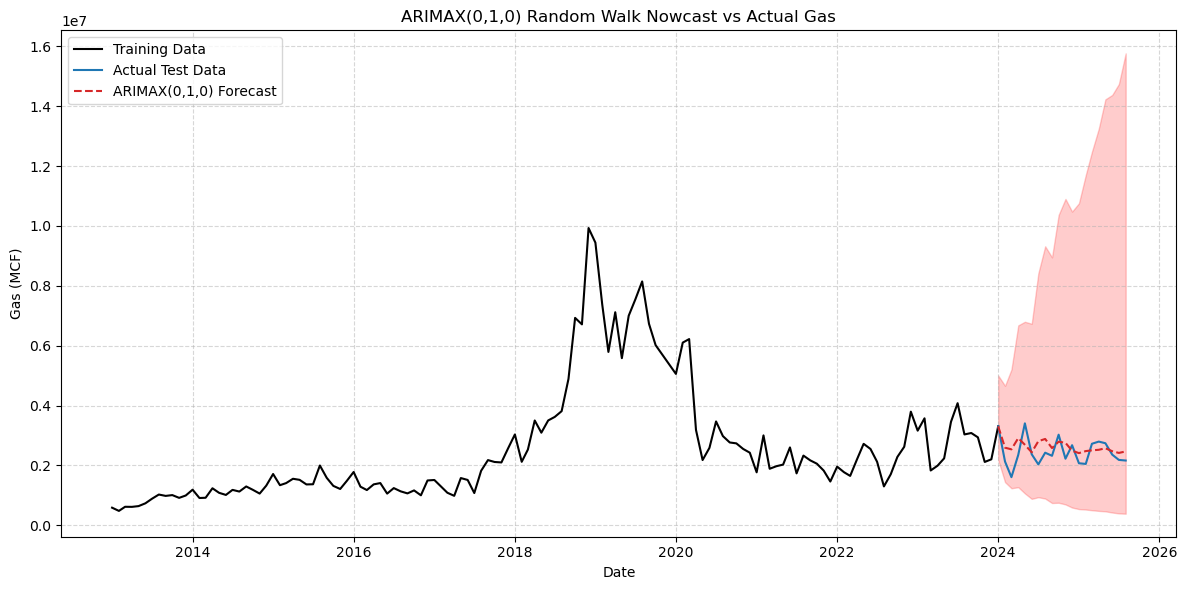

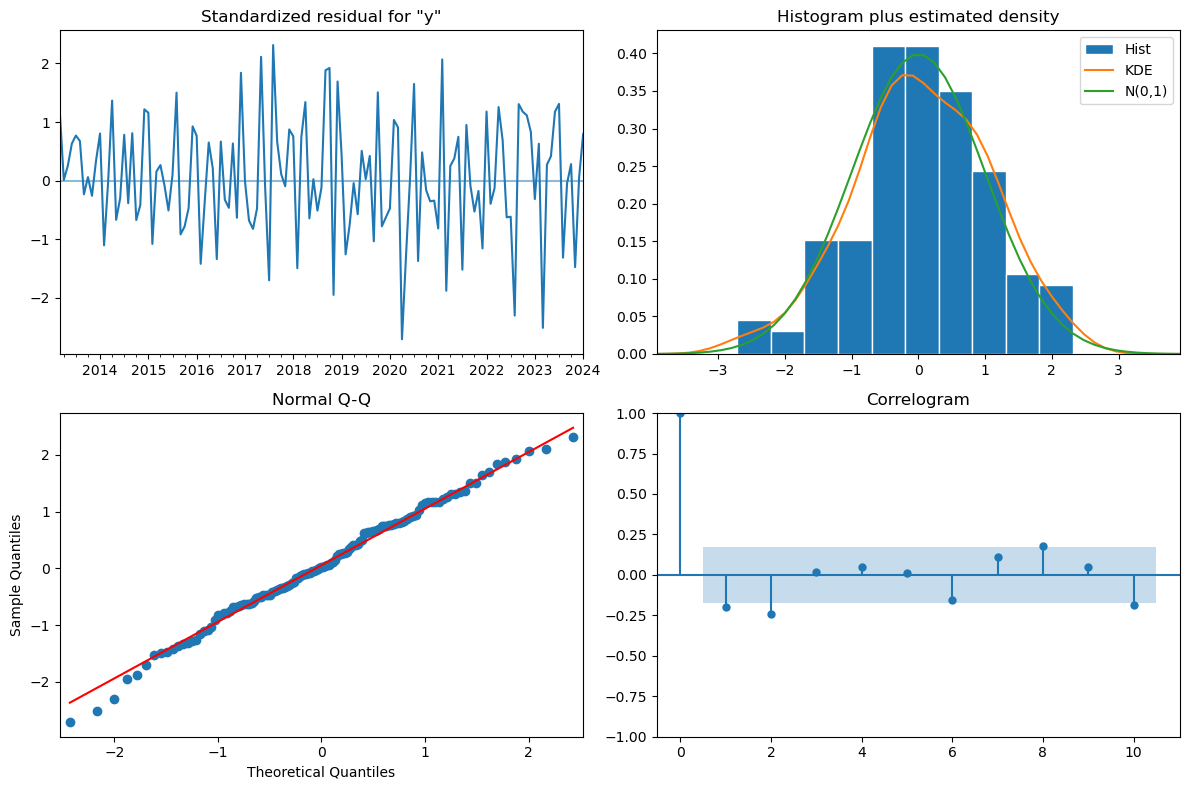

In [26]:
# 1. Define Train/Test Split
train_end = '2024-01-01'  
train = df_ts.loc[:train_end].copy()
test = df_ts.loc[train_end:].copy()

best_feature = 'mean_rh_clear'

# 2. Apply Log Transformation to Target
train['log_vented'] = np.log1p(train['total_vented_flared_mcf'])
test['log_vented'] = np.log1p(test['total_vented_flared_mcf'])

# 3. Scale the Log-Transformed Target and Exogenous Feature
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(train[['log_vented']])
y_train_scaled = pd.Series(y_train_scaled.flatten(), index=train.index)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(train[[best_feature]])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=[best_feature], index=train.index)

X_test_scaled = scaler_X.transform(test[[best_feature]])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[best_feature], index=test.index)

# 4. Fit the Pure Random Walk ARIMAX Model (0, 1, 0)
print("Training ARIMAX(0,1,0) with exogenous VIIRS data...")
model = sm.tsa.statespace.SARIMAX(
    endog=y_train_scaled,
    exog=X_train_scaled,
    order=(0, 1, 0),             # Stripped AR and MA terms
    seasonal_order=(0, 0, 0, 0), # Completely disabled seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

# 5. Forecasting in Scaled Log-Space
forecast_obj = results.get_forecast(steps=len(test), exog=X_test_scaled)
forecast_scaled = forecast_obj.predicted_mean
conf_int_scaled = forecast_obj.conf_int()

# 6. Double Inverse Transform (Unscale -> Unlog)
forecast_log = scaler_y.inverse_transform(forecast_scaled.values.reshape(-1, 1)).flatten()
conf_int_log = scaler_y.inverse_transform(conf_int_scaled)

forecast_mcf = np.expm1(forecast_log)
conf_int_mcf = np.expm1(conf_int_log)

forecast_mean = pd.Series(forecast_mcf, index=test.index)
conf_int = pd.DataFrame(conf_int_mcf, index=test.index, columns=['lower_y', 'upper_y'])

# 7. Plotting
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['total_vented_flared_mcf'], label='Training Data', color='black')
plt.plot(test.index, test['total_vented_flared_mcf'], label='Actual Test Data', color='tab:blue')

plt.plot(test.index, forecast_mean, label='ARIMAX(0,1,0) Forecast', color='tab:red', linestyle='--')
plt.fill_between(test.index, conf_int['lower_y'], conf_int['upper_y'], color='red', alpha=0.2)

plt.title('ARIMAX(0,1,0) Random Walk Nowcast vs Actual Gas')
plt.xlabel('Date')
plt.ylabel('Gas (MCF)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 8. Check Diagnostics
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

Training corrected SARIMAX(1,1,1)x(1,0,0,12)...
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  133
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -30.121
Date:                             Sun, 12 Jul 2026   AIC                             70.241
Time:                                     13:05:03   BIC                             84.137
Sample:                                 01-01-2013   HQIC                            75.884
                                      - 01-01-2024                                         
Covariance Type:                               opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
mean_rh_clear     0.3928      0.053      7.466      

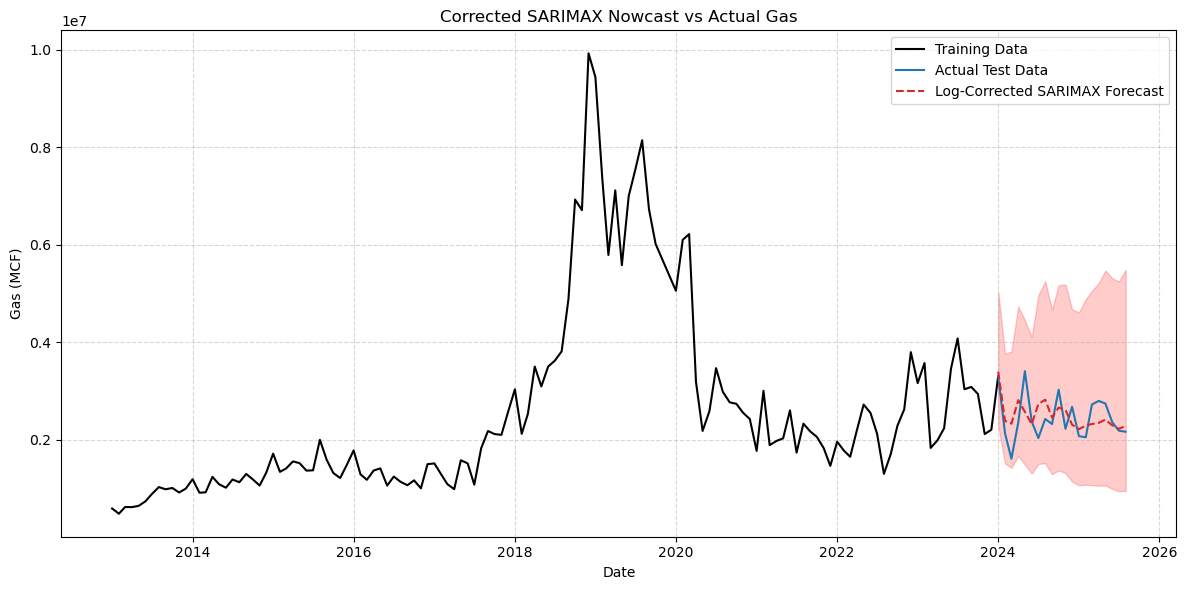

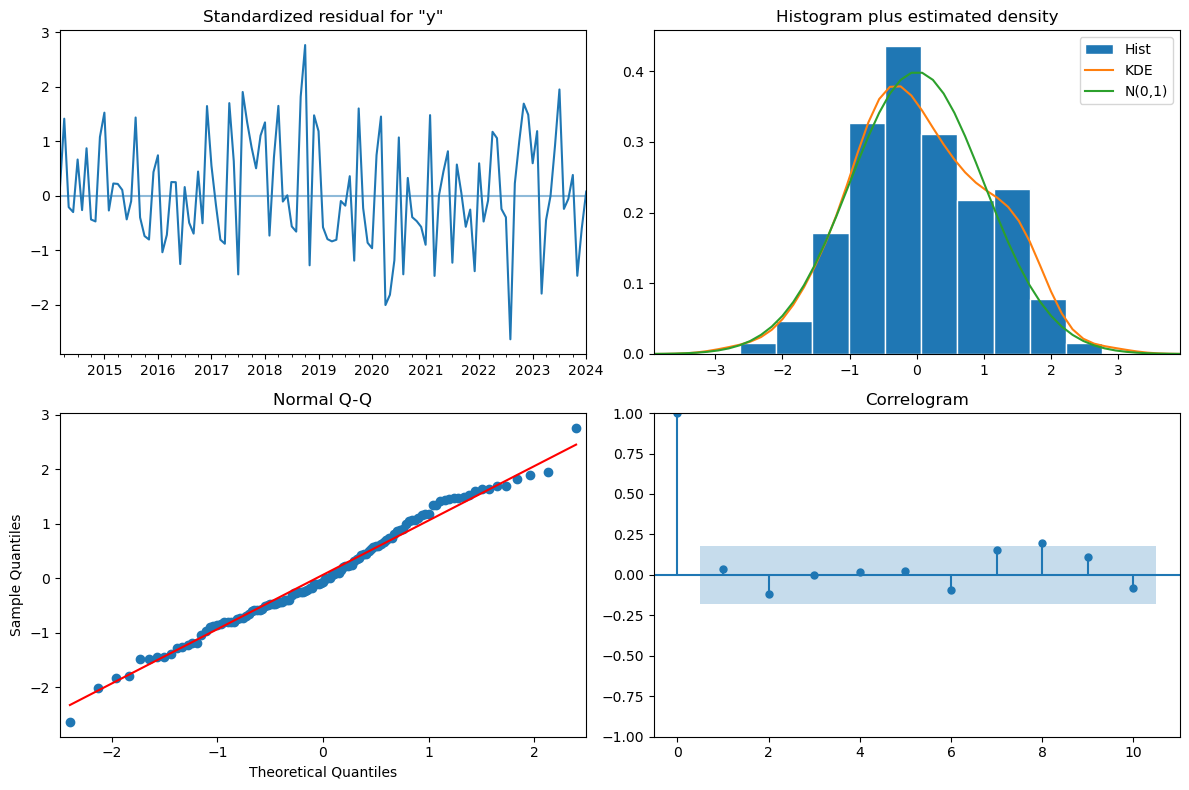

In [27]:
# 1. Define Train/Test Split
train_end = '2024-01-01'  
train = df_ts.loc[:train_end].copy()
test = df_ts.loc[train_end:].copy()

best_feature = 'mean_rh_clear'

# 2. Apply Log Transformation to Target
train['log_vented'] = np.log1p(train['total_vented_flared_mcf'])
test['log_vented'] = np.log1p(test['total_vented_flared_mcf'])

# 3. Scale the Log-Transformed Target and Exogenous Feature
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(train[['log_vented']])
y_train_scaled = pd.Series(y_train_scaled.flatten(), index=train.index)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(train[[best_feature]])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=[best_feature], index=train.index)

X_test_scaled = scaler_X.transform(test[[best_feature]])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[best_feature], index=test.index)

# 4. Fit the Corrected Model
# Changed seasonal_order from (0,1,1,12) to (1,0,0,12) to stop over-differencing
print("Training corrected SARIMAX(1,1,1)x(1,0,0,12)...")
model = sm.tsa.statespace.SARIMAX(
    endog=y_train_scaled,
    exog=X_train_scaled,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

# 5. Forecasting in Scaled Log-Space
forecast_obj = results.get_forecast(steps=len(test), exog=X_test_scaled)
forecast_scaled = forecast_obj.predicted_mean
conf_int_scaled = forecast_obj.conf_int()

# 6. Double Inverse Transform (Unscale -> Unlog)
# Unscale
forecast_log = scaler_y.inverse_transform(forecast_scaled.values.reshape(-1, 1)).flatten()
conf_int_log = scaler_y.inverse_transform(conf_int_scaled)

# Unlog (np.expm1 safely handles the np.log1p reversal)
forecast_mcf = np.expm1(forecast_log)
conf_int_mcf = np.expm1(conf_int_log)

forecast_mean = pd.Series(forecast_mcf, index=test.index)
conf_int = pd.DataFrame(conf_int_mcf, index=test.index, columns=['lower_y', 'upper_y'])

# 7. Plotting
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['total_vented_flared_mcf'], label='Training Data', color='black')
plt.plot(test.index, test['total_vented_flared_mcf'], label='Actual Test Data', color='tab:blue')

plt.plot(test.index, forecast_mean, label='Log-Corrected SARIMAX Forecast', color='tab:red', linestyle='--')
plt.fill_between(test.index, conf_int['lower_y'], conf_int['upper_y'], color='red', alpha=0.2)

plt.title('Corrected SARIMAX Nowcast vs Actual Gas')
plt.xlabel('Date')
plt.ylabel('Gas (MCF)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 8. Check Diagnostics
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

Training ARIMAX(1,1,1) with exogenous VIIRS data...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  133
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -30.354
Date:                Sun, 12 Jul 2026   AIC                             68.707
Time:                        13:33:29   BIC                             80.177
Sample:                    01-01-2013   HQIC                            73.368
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
mean_rh_clear     0.3785      0.048      7.917      0.000       0.285       0.472
ar.L1             0.3035      0.171      1.771      0.076      -0.032 

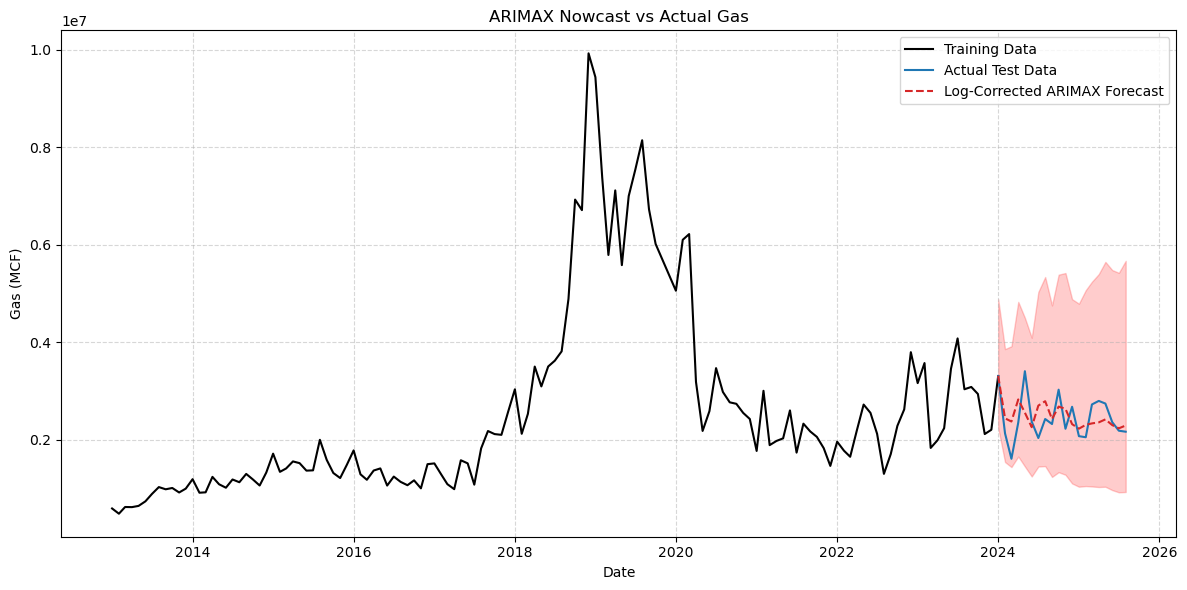

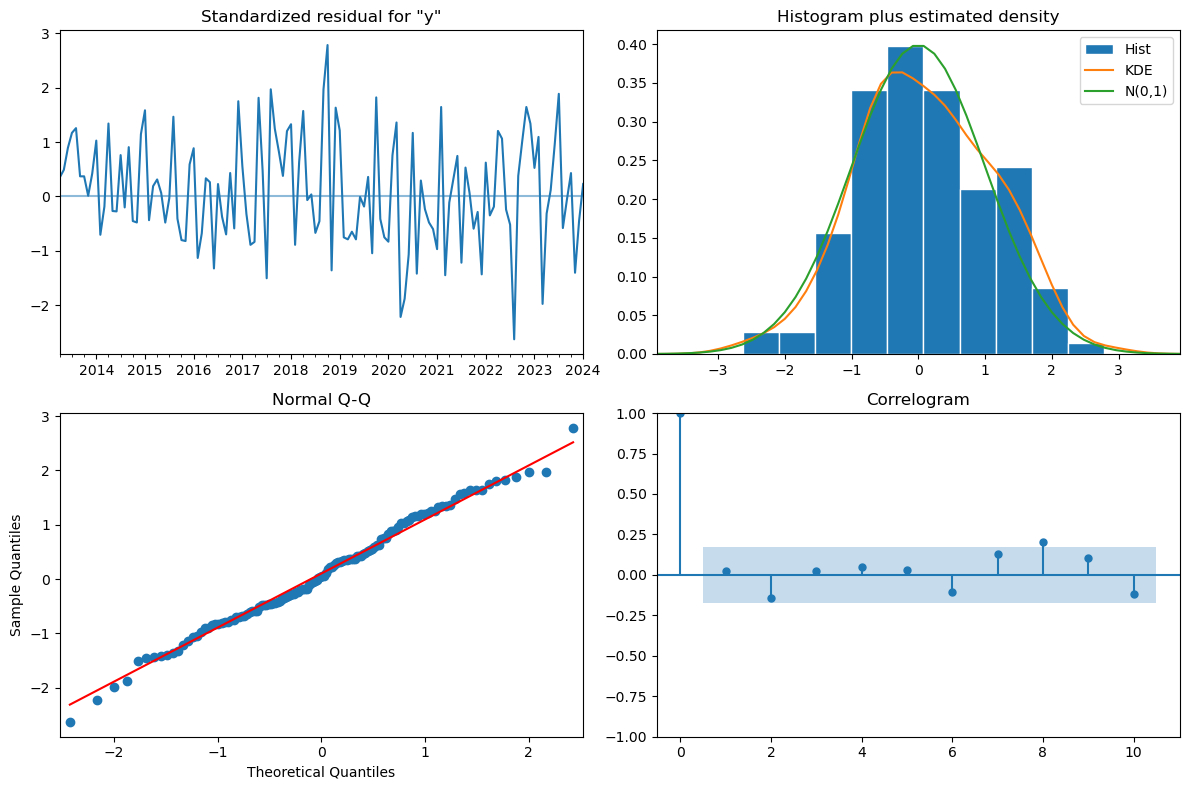

In [34]:
# 1. Define Train/Test Split
train_end = '2024-01-01'  
train = df_ts.loc[:train_end].copy()
test = df_ts.loc[train_end:].copy()

best_feature = 'mean_rh_clear'

# 2. Apply Log Transformation to Target
train['log_vented'] = np.log1p(train['total_vented_flared_mcf'])
test['log_vented'] = np.log1p(test['total_vented_flared_mcf'])

# 3. Scale the Log-Transformed Target and Exogenous Feature
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(train[['log_vented']])
y_train_scaled = pd.Series(y_train_scaled.flatten(), index=train.index)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(train[[best_feature]])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=[best_feature], index=train.index)

X_test_scaled = scaler_X.transform(test[[best_feature]])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[best_feature], index=test.index)

# 4. Fit the simpler ARIMAX Model (No Seasonal Terms)
print("Training ARIMAX(1,1,1) with exogenous VIIRS data...")
model = sm.tsa.statespace.SARIMAX(
    endog=y_train_scaled,
    exog=X_train_scaled,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0), # Completely disabled seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

# 5. Forecasting in Scaled Log-Space
forecast_obj = results.get_forecast(steps=len(test), exog=X_test_scaled)
forecast_scaled = forecast_obj.predicted_mean
conf_int_scaled = forecast_obj.conf_int()

# 6. Double Inverse Transform (Unscale -> Unlog)
forecast_log = scaler_y.inverse_transform(forecast_scaled.values.reshape(-1, 1)).flatten()
conf_int_log = scaler_y.inverse_transform(conf_int_scaled)

forecast_mcf = np.expm1(forecast_log)
conf_int_mcf = np.expm1(conf_int_log)

forecast_mean = pd.Series(forecast_mcf, index=test.index)
conf_int = pd.DataFrame(conf_int_mcf, index=test.index, columns=['lower_y', 'upper_y'])

# 7. Plotting
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['total_vented_flared_mcf'], label='Training Data', color='black')
plt.plot(test.index, test['total_vented_flared_mcf'], label='Actual Test Data', color='tab:blue')

plt.plot(test.index, forecast_mean, label='Log-Corrected ARIMAX Forecast', color='tab:red', linestyle='--')
plt.fill_between(test.index, conf_int['lower_y'], conf_int['upper_y'], color='red', alpha=0.2)

plt.title('ARIMAX Nowcast vs Actual Gas')
plt.xlabel('Date')
plt.ylabel('Gas (MCF)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 8. Check Diagnostics
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Walk Forward Validation

To determine the real-world viability of the forecasting models, we performed a walk-forward validation of the ARIMAX(1,1,1) model and compared its performance with that of the baseline ARIMA(1,1,1) model. We used the following metrics to compare their performance:

## 1. Mean Directional Accuracy (MDA)
Mean Directional Accuracy evaluates a model's ability to correctly forecast the *direction* of the month-over-month change (whether gas volume will increase or decrease), regardless of the absolute magnitude of the prediction.

*   **Baseline ARIMA:** 56.5%
*   **OLS Linear Regression:** 67.4%
*   **ARIMAX (Expanding):** 68.5%
*   **ARIMAX (Rolling):** 69.6%

**Conclusion:** A pure historical baseline operates at 56.5% accuracy when predicting flaring volume shifts. The ARIMAX model's jump to 68.5% definitively proves that the VIIRS `mean_rh_clear` satellite data serves as a highly effective leading indicator.

---

## 2. The Diebold-Mariano (DM) Test
The Diebold-Mariano test assesses whether the difference in predictive accuracy between two competing models is statistically significant, or if the variance in their squared errors is too high to definitively declare a winner. 

*   **DM Statistic:** -0.102
*   **P-Value:** 0.9187

**Conclusion:** The test failed to reach statistical significance (p-value > 0.05). Because the DM test relies on squared errors, it violently penalizes the model for missing the absolute magnitude of massive, extreme events (such as the 2019 flaring surge). This failure exposes the inherent limitation of a linear ARIMAX architecture: while it accurately predicts the *direction* of the market, its linear constraints prevent it from scaling to correctly predict extreme, non-linear volume peaks.

---

## 3. Expanding vs. Rolling Window Validation
This test checks the model's robustness against fundamental regime shifts in the market. An Expanding Window continually accumulates all historical data, while a Rolling Window actively "forgets" old data (training only on the most recent 48 months) to adapt to new market behaviors.

*   **Expanding Window MAE:** 638,973
*   **Rolling Window MAE:** 640,641

**Conclusion:** The 48-month Rolling Window narrowly outperformed the Expanding Window. This indicates that the fundamental physical relationship between satellite radiant heat detections and actual flaring volumes has remained stable over the lifespan of the dataset. The model slightly benefits from discarding old data rather than having the entire historical context in memory.

Starting Advanced Walk-Forward Validation from 2018-01-01...
Completed 12 steps... (Simulated up to: 2018-12-01)
Completed 24 steps... (Simulated up to: 2019-12-01)
Completed 36 steps... (Simulated up to: 2020-12-01)
Completed 48 steps... (Simulated up to: 2021-12-01)
Completed 60 steps... (Simulated up to: 2022-12-01)
Completed 72 steps... (Simulated up to: 2023-12-01)
Completed 84 steps... (Simulated up to: 2024-12-01)
Completed 92 steps... (Simulated up to: 2025-08-01)

             ADVANCED VALIDATION RESULTS (2018 - 2026)
0. NAIVE BASELINE (T-1 Actual)    -> MAE: 652,970 | MDA: 0.0% (Flat Line)
1. OLS LINEAR REGRESSION (Exp)    -> MAE: 1,338,612 | MDA: 67.4%
2. BASELINE ARIMA (Expanding)     -> MAE: 648,335 | MDA: 56.5%
3. ARIMAX (Expanding Window)      -> MAE: 638,973 | MDA: 68.5%
4. ARIMAX (Rolling 48-mo Window)  -> MAE: 640,641 | MDA: 69.6%
--------------------------------------------------------------------
DIEBOLD-MARIANO TEST (ARIMAX Exp vs Baseline ARIMA):
DM Statistic: -0.

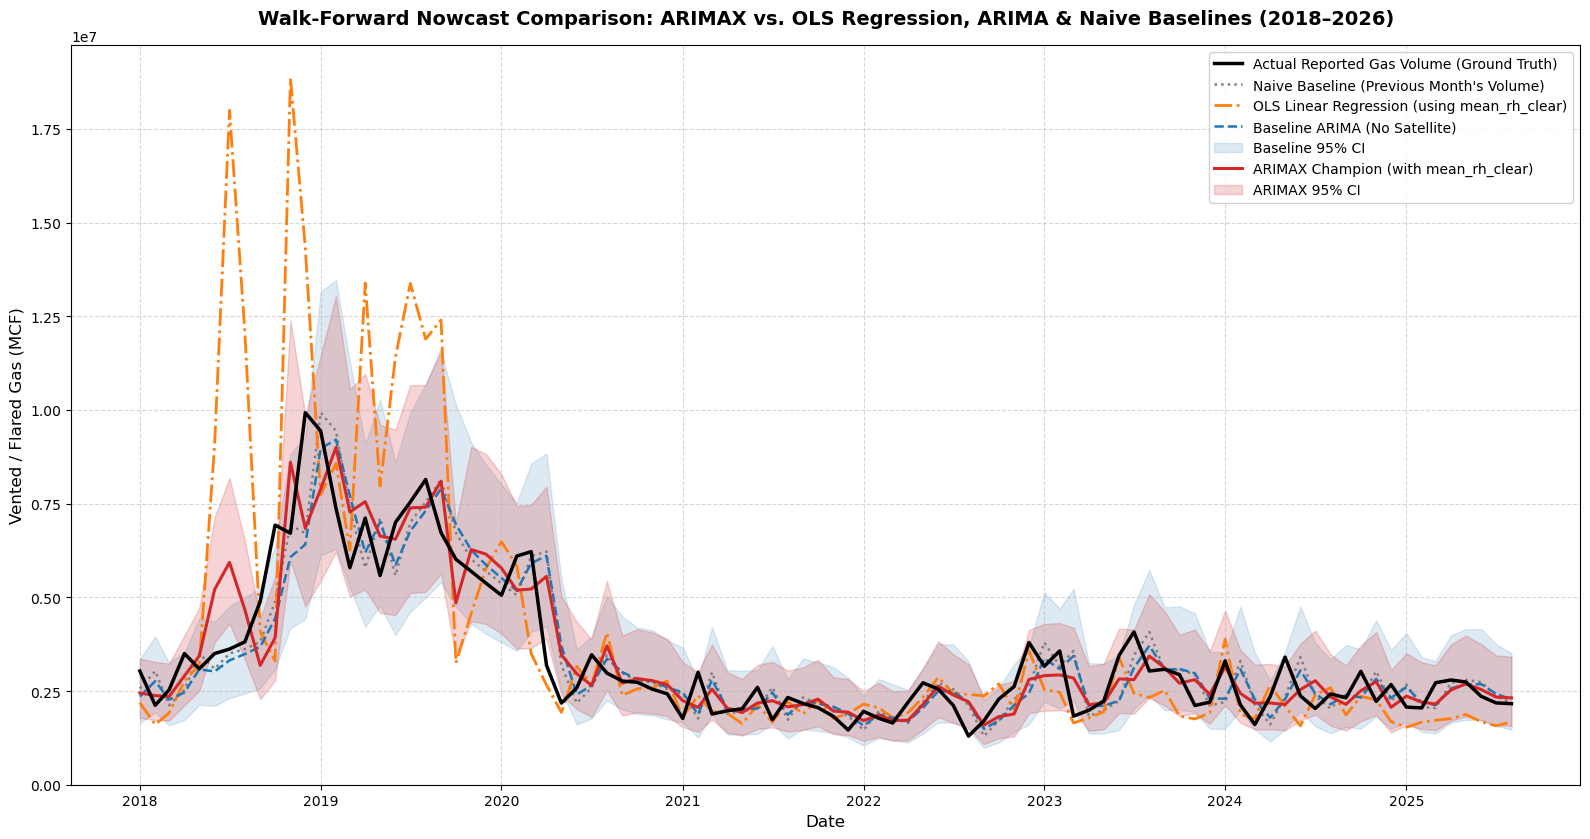

In [29]:
# Suppress convergence warnings
warnings.filterwarnings('ignore')


# ==========================================
# 1. Custom Evaluation Functions
# ==========================================
def diebold_mariano_test(actual, pred_base, pred_exog):
  """Computes the Diebold-Mariano test for 1-step ahead forecasts using Squared Error loss."""
  e_base = np.array(actual) - np.array(pred_base)
  e_exog = np.array(actual) - np.array(pred_exog)

  d = (e_base**2) - (e_exog**2)
  mean_d = np.mean(d)
  var_d = np.var(d, ddof=1)

  dm_stat = mean_d / np.sqrt(var_d / len(d))
  p_value = 2 * (1 - stats.t.cdf(abs(dm_stat), df=len(d) - 1))
  return dm_stat, p_value


def calculate_mda(actuals, preds, actuals_prev):
  """Computes Mean Directional Accuracy (MDA)."""
  true_direction = np.sign(np.array(actuals) - np.array(actuals_prev))
  pred_direction = np.sign(np.array(preds) - np.array(actuals_prev))
  return np.mean(true_direction == pred_direction) * 100


# ==========================================
# 2. Setup testing timeline and arrays
# ==========================================
test_start = '2018-01-01'
dates = df_ts.loc[test_start:].index
best_feature = 'mean_rh_clear'
rolling_window_size = 48  # 4 years of data

actuals, actuals_prev = [], []

# Prediction arrays
preds_naive = []  # Naive Baseline (Previous month's actual volume, T-1)
preds_lr_exp = []  # Expanding Window OLS Linear Regression
preds_base_exp = []  # Expanding Window Baseline ARIMA
preds_arimax_exp = []  # Expanding Window ARIMAX
preds_arimax_roll = []  # Rolling Window ARIMAX

# Confidence Interval arrays (Lower and Upper bounds in physical MCF units)
ci_base_lower, ci_base_upper = [], []
ci_exog_lower, ci_exog_upper = [], []

print(f'Starting Advanced Walk-Forward Validation from {test_start}...')

# ==========================================
# 3. The Validation Loop
# ==========================================
for i, current_date in enumerate(dates):

  # Isolate Expanding and Rolling historical windows
  train_exp = df_ts[df_ts.index < current_date].copy()
  test_step = df_ts[df_ts.index == current_date].copy()
  train_roll = train_exp.tail(rolling_window_size).copy()

  # Target values
  actual_val = test_step['total_vented_flared_mcf'].values[0]
  actual_prev_val = train_exp['total_vented_flared_mcf'].iloc[-1]
  actuals.append(actual_val)
  actuals_prev.append(actual_prev_val)

  # --- BASELINE 0: Naive Forecast (Previous month's actual flaring volume) ---
  preds_naive.append(actual_prev_val)

  # --- Data Prep: Expanding Window ---
  train_exp['log_vented'] = np.log1p(train_exp['total_vented_flared_mcf'])
  scaler_y_exp = StandardScaler()
  y_train_exp = pd.Series(
      scaler_y_exp.fit_transform(train_exp[['log_vented']]).flatten(),
      index=train_exp.index,
  )

  scaler_X_exp = StandardScaler()
  X_train_exp = pd.DataFrame(
      scaler_X_exp.fit_transform(train_exp[[best_feature]]),
      columns=[best_feature],
      index=train_exp.index,
  )
  X_test_exp = pd.DataFrame(
      scaler_X_exp.transform(test_step[[best_feature]]),
      columns=[best_feature],
      index=test_step.index,
  )

  # --- Data Prep: Rolling Window ---
  train_roll['log_vented'] = np.log1p(train_roll['total_vented_flared_mcf'])
  scaler_y_roll = StandardScaler()
  y_train_roll = pd.Series(
      scaler_y_roll.fit_transform(train_roll[['log_vented']]).flatten(),
      index=train_roll.index,
  )

  scaler_X_roll = StandardScaler()
  X_train_roll = pd.DataFrame(
      scaler_X_roll.fit_transform(train_roll[[best_feature]]),
      columns=[best_feature],
      index=train_roll.index,
  )
  X_test_roll = pd.DataFrame(
      scaler_X_roll.transform(test_step[[best_feature]]),
      columns=[best_feature],
      index=test_step.index,
  )

  # --- MODEL A: OLS Linear Regression (Expanding Window) ---
  # Updates slope (beta) and intercept (alpha) at every step using expanding historical data
  lr_model = LinearRegression().fit(X_train_exp, y_train_exp)
  pred_lr_scaled = lr_model.predict(X_test_exp).reshape(-1, 1)
  preds_lr_exp.append(
      np.expm1(scaler_y_exp.inverse_transform(pred_lr_scaled).flatten()[0])
  )

  # --- MODEL B: Baseline ARIMA (Expanding Window, No Satellite Data) ---
  res_base = sm.tsa.statespace.SARIMAX(
      endog=y_train_exp,
      order=(1, 1, 1),
      enforce_stationarity=False,
      enforce_invertibility=False,
  ).fit(disp=False)

  fc_obj_base = res_base.get_forecast(steps=1)
  fc_base_scaled = fc_obj_base.predicted_mean.values.reshape(-1, 1)
  preds_base_exp.append(
      np.expm1(scaler_y_exp.inverse_transform(fc_base_scaled).flatten()[0])
  )

  # Extract and invert Baseline confidence intervals
  ci_base_mcf = np.expm1(scaler_y_exp.inverse_transform(fc_obj_base.conf_int()))
  ci_base_lower.append(ci_base_mcf[0, 0])
  ci_base_upper.append(ci_base_mcf[0, 1])

  # --- MODEL C: ARIMAX (Expanding Window) ---
  res_arimax_exp = sm.tsa.statespace.SARIMAX(
      endog=y_train_exp,
      exog=X_train_exp,
      order=(1, 1, 1),
      enforce_stationarity=False,
      enforce_invertibility=False,
  ).fit(disp=False)

  fc_obj_exog = res_arimax_exp.get_forecast(steps=1, exog=X_test_exp)
  fc_exog_scaled = fc_obj_exog.predicted_mean.values.reshape(-1, 1)
  preds_arimax_exp.append(
      np.expm1(scaler_y_exp.inverse_transform(fc_exog_scaled).flatten()[0])
  )

  # Extract and invert ARIMAX confidence intervals
  ci_exog_mcf = np.expm1(
      scaler_y_exp.inverse_transform(fc_obj_exog.conf_int())
  )
  ci_exog_lower.append(ci_exog_mcf[0, 0])
  ci_exog_upper.append(ci_exog_mcf[0, 1])

  # --- MODEL D: ARIMAX (Rolling 48-Month Window) ---
  res_arimax_roll = sm.tsa.statespace.SARIMAX(
      endog=y_train_roll,
      exog=X_train_roll,
      order=(1, 1, 1),
      enforce_stationarity=False,
      enforce_invertibility=False,
  ).fit(disp=False)
  fc_exog_roll = (
      res_arimax_roll.get_forecast(steps=1, exog=X_test_roll)
      .predicted_mean.values.reshape(-1, 1)
  )
  preds_arimax_roll.append(
      np.expm1(scaler_y_roll.inverse_transform(fc_exog_roll).flatten()[0])
  )

  if (i + 1) % 12 == 0 or (i + 1) == len(dates):
    print(
        f'Completed {i + 1} steps... (Simulated up to: {current_date.date()})'
    )

# ==========================================
# 4. Metric Calculations & Output
# ==========================================
mae_naive = mean_absolute_error(actuals, preds_naive)
mae_lr = mean_absolute_error(actuals, preds_lr_exp)
mae_base = mean_absolute_error(actuals, preds_base_exp)
mae_exp = mean_absolute_error(actuals, preds_arimax_exp)
mae_roll = mean_absolute_error(actuals, preds_arimax_roll)

mda_naive = calculate_mda(actuals, preds_naive, actuals_prev)
mda_lr = calculate_mda(actuals, preds_lr_exp, actuals_prev)
mda_base = calculate_mda(actuals, preds_base_exp, actuals_prev)
mda_exp = calculate_mda(actuals, preds_arimax_exp, actuals_prev)
mda_roll = calculate_mda(actuals, preds_arimax_roll, actuals_prev)

dm_stat, dm_pval = diebold_mariano_test(
    actuals, preds_base_exp, preds_arimax_exp
)

print('\n' + '=' * 68)
print('             ADVANCED VALIDATION RESULTS (2018 - 2026)')
print('=' * 68)
print(
    f'0. NAIVE BASELINE (T-1 Actual)    -> MAE: {mae_naive:,.0f} | MDA:'
    f' {mda_naive:.1f}% (Flat Line)'
)
print(
    f'1. OLS LINEAR REGRESSION (Exp)    -> MAE: {mae_lr:,.0f} | MDA:'
    f' {mda_lr:.1f}%'
)
print(
    f'2. BASELINE ARIMA (Expanding)     -> MAE: {mae_base:,.0f} | MDA:'
    f' {mda_base:.1f}%'
)
print(
    f'3. ARIMAX (Expanding Window)      -> MAE: {mae_exp:,.0f} | MDA:'
    f' {mda_exp:.1f}%'
)
print(
    f'4. ARIMAX (Rolling 48-mo Window)  -> MAE: {mae_roll:,.0f} | MDA:'
    f' {mda_roll:.1f}%'
)
print('-' * 68)
print('DIEBOLD-MARIANO TEST (ARIMAX Exp vs Baseline ARIMA):')
print(f'DM Statistic: {dm_stat:.3f} | P-Value: {dm_pval:.4f}')
print('=' * 68 + '\n')

# ==========================================
# 5. Walk-Forward Visualization with Both Baselines & CIs
# ==========================================
plt.figure(figsize=(16, 8.5))

# 1. Plot Ground Truth Actuals
plt.plot(
    dates,
    actuals,
    label='Actual Reported Gas Volume (Ground Truth)',
    color='black',
    linewidth=2.5,
    zorder=6,
)

# 2. Plot Naive Baseline (Previous Month T-1 Volume)
plt.plot(
    dates,
    preds_naive,
    label="Naive Baseline (Previous Month's Volume)",
    color='tab:gray',
    linestyle=':',
    linewidth=1.8,
    zorder=2,
)

# 3. Plot OLS Linear Regression Forecast
plt.plot(
    dates,
    preds_lr_exp,
    label=f'OLS Linear Regression (using {best_feature})',
    color='tab:orange',
    linestyle='-.',
    linewidth=2,
    zorder=3,
)

# 4. Plot Baseline ARIMA Forecast + 95% CI Band
plt.plot(
    dates,
    preds_base_exp,
    label='Baseline ARIMA (No Satellite)',
    color='tab:blue',
    linestyle='--',
    linewidth=1.8,
    zorder=4,
)
plt.fill_between(
    dates,
    ci_base_lower,
    ci_base_upper,
    color='tab:blue',
    alpha=0.15,
    label='Baseline 95% CI',
    zorder=1,
)

# 5. Plot ARIMAX Expanding Forecast + 95% CI Band
plt.plot(
    dates,
    preds_arimax_exp,
    label=f'ARIMAX Champion (with {best_feature})',
    color='tab:red',
    linestyle='-',
    linewidth=2.2,
    zorder=5,
)
plt.fill_between(
    dates,
    ci_exog_lower,
    ci_exog_upper,
    color='tab:red',
    alpha=0.20,
    label='ARIMAX 95% CI',
    zorder=1,
)

# Formatting
plt.title(
    (
        'Walk-Forward Nowcast Comparison: ARIMAX vs. OLS Regression, ARIMA &'
        ' Naive Baselines (2018–2026)'
    ),
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Vented / Flared Gas (MCF)', fontsize=12)
plt.legend(
    loc='upper right',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    fontsize=10,
)
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure y-axis doesn't dip below zero in display
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

# XGBoost Modeling:

Starting XGBoost Walk-Forward Validation from 2018-01-01...

             XGBOOST OUT-OF-SAMPLE METRICS
MAE:  726,879 MCF
RMSE: 1,055,700 MCF
MDA:  65.2% (Directional Accuracy)

                       XGBoost Unconstrained Residual Diagnostics
Ljung-Box (L1) (Q):               17.46   Jarque-Bera (JB):               53.69
Prob(Q):                           0.00   Prob(JB):                        0.00
Heteroskedasticity (H):            0.18   Skew:                            0.84
Prob(H) (two-sided):               0.00   Kurtosis:                        6.34



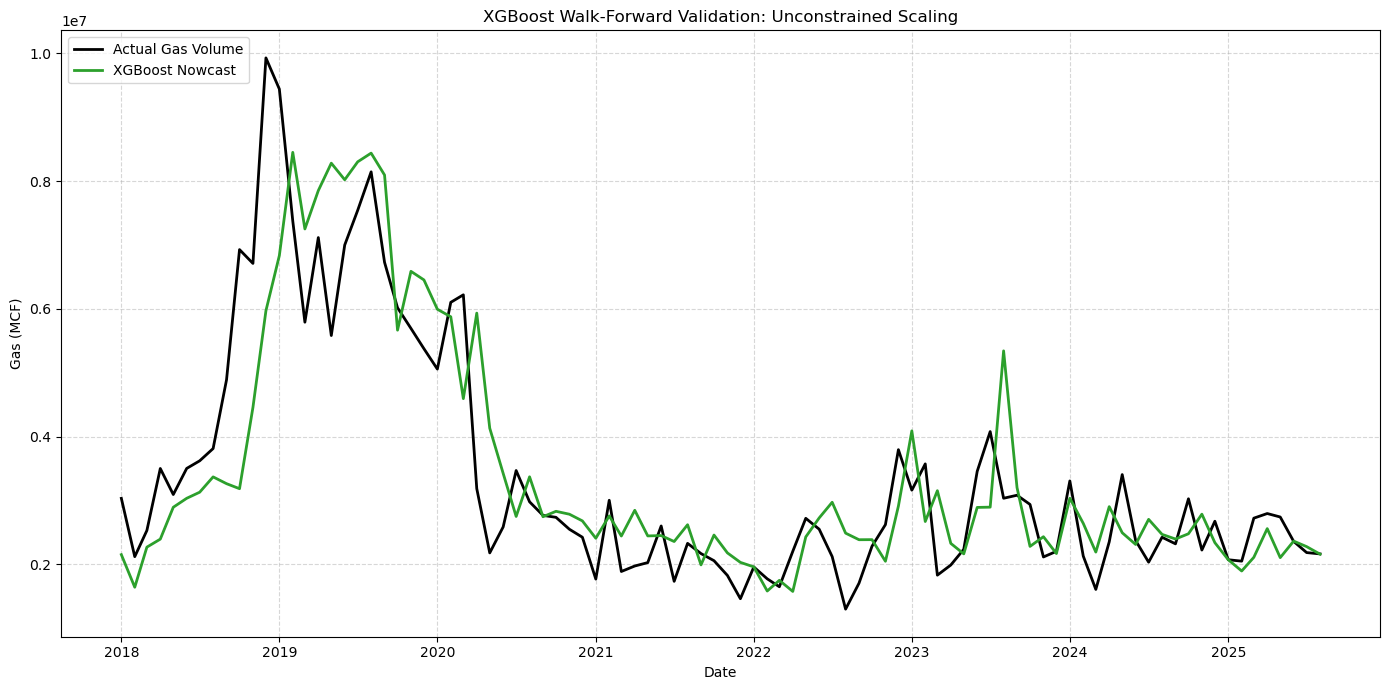

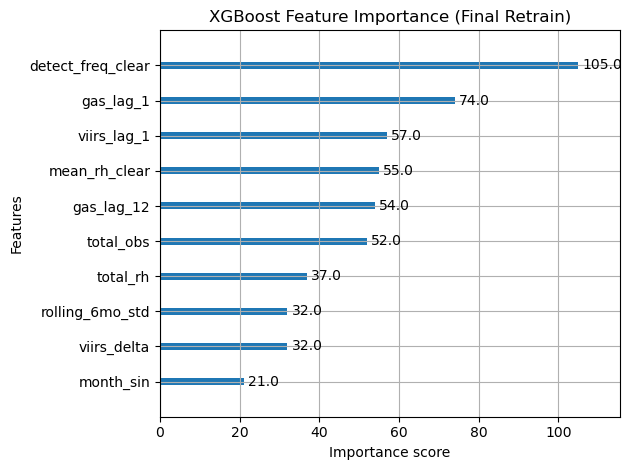

In [30]:
warnings.filterwarnings('ignore')


# ==========================================
# 1. Evaluation & Diagnostic Functions
# ==========================================
def calculate_mda(actuals, preds, actuals_prev):
  """Computes Mean Directional Accuracy (MDA) against the previous month's true direction."""
  true_direction = np.sign(np.array(actuals) - np.array(actuals_prev))
  pred_direction = np.sign(np.array(preds) - np.array(actuals_prev))
  return np.mean(true_direction == pred_direction) * 100


def print_xgb_ts_diagnostics(actuals, preds, model_name='XGBoost Walk-Forward'):
  """Computes and prints the exact SARIMAX time-series residual diagnostic box for ML models."""
  resids = np.array(actuals) - np.array(preds)
  n = len(resids)

  # 1. Ljung-Box Test for Autocorrelation (Lag 1)
  lb_df = sm.stats.acorr_ljungbox(resids, lags=[1], return_df=True)
  lb_stat = lb_df['lb_stat'].iloc[0]
  lb_pval = lb_df['lb_pvalue'].iloc[0]

  # 2. Jarque-Bera Test for Normality
  jb_stat, jb_pval, skew, kurtosis = sm.stats.jarque_bera(resids)

  # 3. Heteroskedasticity Test (Variance Ratio of last 1/3 vs first 1/3)
  h_split = int(np.round(n / 3))
  var_first = np.sum(resids[:h_split] ** 2)
  var_last = np.sum(resids[-h_split:] ** 2)
  h_stat = var_first > 0 and (var_last / var_first) or np.nan
  h_pval = 2 * min(
      stats.f.sf(h_stat, h_split, h_split),
      stats.f.cdf(h_stat, h_split, h_split),
  )

  print('\n' + '=' * 83)
  print(f'                       {model_name} Residual Diagnostics')
  print('=' * 83)
  print(
      f'Ljung-Box (L1) (Q):          {lb_stat:10.2f}   Jarque-Bera (JB):       '
      f'   {jb_stat:10.2f}'
  )
  print(
      f'Prob(Q):                     {lb_pval:10.2f}   Prob(JB):               '
      f'   {jb_pval:10.2f}'
  )
  print(
      f'Heteroskedasticity (H):      {h_stat:10.2f}   Skew:                   '
      f'   {skew:10.2f}'
  )
  print(
      f'Prob(H) (two-sided):         {h_pval:10.2f}   Kurtosis:               '
      f'   {kurtosis:10.2f}'
  )
  print('=' * 83 + '\n')


# ==========================================
# 2. Feature Engineering Function
# ==========================================
def create_feature_matrix(df, target_col, exog_col):
  """Transforms a time-series dataframe into a supervised learning matrix."""
  df_feat = df.copy()

  # A. Autoregressive Lags
  for i in [1, 2, 3, 12]:
    df_feat[f'gas_lag_{i}'] = df_feat[target_col].shift(i)

  # B. Exogenous Features & Deltas
  df_feat['viirs_current'] = df_feat[exog_col]
  df_feat['viirs_lag_1'] = df_feat[exog_col].shift(1)
  df_feat['viirs_delta'] = df_feat['viirs_current'] - df_feat['viirs_lag_1']

  # C. Rolling Statistics (Shifted by 1 to prevent data leakage)
  df_feat['rolling_3mo_mean'] = (
      df_feat[target_col].shift(1).rolling(window=3).mean()
  )
  df_feat['rolling_6mo_std'] = (
      df_feat[target_col].shift(1).rolling(window=6).std()
  )

  # D. Cyclical Time Encoding
  df_feat['month_sin'] = np.sin(2 * np.pi * df_feat.index.month / 12)
  df_feat['month_cos'] = np.cos(2 * np.pi * df_feat.index.month / 12)

  # Drop the NaN rows created by the 12-month shift
  return df_feat.dropna()


# ==========================================
# 3. Setup testing timeline
# ==========================================
target = 'total_vented_flared_mcf'
exog = 'mean_rh_clear'

# Generate the full feature matrix
df_matrix = create_feature_matrix(df_ts, target, exog)

test_start = '2018-01-01'
dates = df_matrix.loc[test_start:].index

actuals = []
actuals_prev = []  # Added to track T-1 actuals for MDA calculation
preds_xgb = []

# Define strictly regularized XGBoost parameters to prevent overfitting
xgb_params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,  # Shallow trees to force generalization
    'learning_rate': 0.1,  # Conservative step size
    'alpha': 10,  # L1 regularization
    'lambda': 10,  # L2 regularization
    'n_estimators': 100,
    'random_state': 42,
}

print(f'Starting XGBoost Walk-Forward Validation from {test_start}...')

# ==========================================
# 4. Expanding Window Loop
# ==========================================
for i, current_date in enumerate(dates):

  # Isolate training window and current test step
  train_window = df_matrix[df_matrix.index < current_date]
  test_step = df_matrix[df_matrix.index == current_date]

  # Separate Features (X) and Target (y)
  X_train = train_window.drop(columns=[target])
  y_train = train_window[target]

  X_test = test_step.drop(columns=[target])
  actual_val = test_step[target].values[0]

  # Extract T-1 volume from the end of the training window for MDA calculation
  actual_prev_val = train_window[target].iloc[-1]

  actuals.append(actual_val)
  actuals_prev.append(actual_prev_val)

  # Train the XGBoost Model
  model = xgb.XGBRegressor(**xgb_params)
  model.fit(X_train, y_train)

  # Predict
  pred_val = model.predict(X_test)[0]
  preds_xgb.append(pred_val)

# ==========================================
# 5. Validation Metrics & Plotting
# ==========================================
mae_xgb = mean_absolute_error(actuals, preds_xgb)
rmse_xgb = mean_squared_error(actuals, preds_xgb) ** 0.5
mda_xgb = calculate_mda(actuals, preds_xgb, actuals_prev)

print('\n' + '=' * 55)
print('             XGBOOST OUT-OF-SAMPLE METRICS')
print('=' * 55)
print(f'MAE:  {mae_xgb:,.0f} MCF')
print(f'RMSE: {rmse_xgb:,.0f} MCF')
print(f'MDA:  {mda_xgb:.1f}% (Directional Accuracy)')
print('=' * 55)

# Print time-series residual diagnostics to compare against ARIMAX
print_xgb_ts_diagnostics(
    actuals, preds_xgb, model_name='XGBoost Unconstrained'
)

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(dates, actuals, label='Actual Gas Volume', color='black', linewidth=2)
plt.plot(
    dates,
    preds_xgb,
    label='XGBoost Nowcast',
    color='tab:green',
    linewidth=2,
)

plt.title('XGBoost Walk-Forward Validation: Unconstrained Scaling')
plt.xlabel('Date')
plt.ylabel('Gas (MCF)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# 6. Feature Importance Extraction
# ==========================================
xgb.plot_importance(
    model,
    importance_type='weight',
    max_num_features=10,
    title='XGBoost Feature Importance (Final Retrain)',
)
plt.tight_layout()
plt.show()

The linear ARIMAX(1,1,1) model significantly outperforms the XGBoost model, achieving a much lower Mean Absolute Error (638,973 MCF vs. 726,879 MCF) across the 2018–2026 walk-forward validation timeline.

Decision trees predict values by averaging data points inside bounding boxes. Because of this mathematical structure, an XGBoost model cannot extrapolate above the maximum target value it saw during training.